<h1><center>NEMREG INFORMATION</center></h1>

### Check Dependencies

As a first step the user needs to ensure that these packages and libraries are installed which can be checked by these lines of code. If one of the libraries is missing, please download the missing packages and/or libraries. Debugging tip, see if the place you download hte libraries is the same place/ kernel you are currently using. E.g, if you have multiple ```.venv``` check if it downloaded into the right one. 



If the following code runs without problem, all is good. If not the code should tell what is missing. 

In [33]:
# =====================================
# nemreg dependency check
# =====================================

import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print()

required_packages = [
    "numpy",
    "scipy",
    "matplotlib",
]

missing = []

for pkg in required_packages:
    try:
        __import__(pkg)
        print(f"✓ {pkg} imported successfully")
    except ImportError:
        print(f"✗ {pkg} NOT installed")
        missing.append(pkg)

print()

try:
    import nemreg as nr
    print("✓ nemreg imported successfully")
    print("nemreg path:", nr.__file__)
except Exception as e:
    print("✗ nemreg failed to import")
    print(e)
    missing.append("nemreg")

if missing:
    print("\n⚠ Missing packages:", missing)
    print("Install with:")
    print("pip install " + " ".join(missing))
else:
    print("\n✅ All dependencies available. Ready to go.")

Python executable: /Users/nemeth/Programing/DTU_Programming/dtu-env/bin/python
Python version: 3.10.6 (v3.10.6:9c7b4bd164, Aug  1 2022, 17:13:48) [Clang 13.0.0 (clang-1300.0.29.30)]

✓ numpy imported successfully
✓ scipy imported successfully
✓ matplotlib imported successfully

✓ nemreg imported successfully
nemreg path: /Users/nemeth/Programing/DTU_Programming/Test/nemreg/src/nemreg/__init__.py

✅ All dependencies available. Ready to go.


One can also check further by running the following commandline from the root of the library to check that there is no broken update. ```python -m pytest -v```

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import nemreg as nr

# NEMREG Demo

Below is an overview of the main public functions in **nemreg** and the parameters they accept.

---

## Core Objects

### `nr.Dataset(...)`

Create a dataset for regression.

```python
nr.Dataset(
    x,
    y,
    xerr=None,
    yerr=None,
    xlabel=None,
    ylabel=None,
    xunit=None,
    yunit=None,
    name=None,
)
```

**Parameters:**
- `x` → array-like, shape `(n,)` or `(n,d)`
- `y` → array-like, shape `(n,)`
- `xerr` → optional uncertainties in x
- `yerr` → optional uncertainties in y
- `xlabel`, `ylabel` → axis labels
- `xunit`, `yunit` → axis units
- `name` → dataset name

---

### `nr.Dataset.from_replicates(...)`

Create dataset from repeated measurements.

```python
nr.Dataset.from_replicates(
    x,
    Y,
    yerr_mode="std",   # "std" or "sem"
    global_error=False,
    **kwargs
)
```

**Parameters:**
- `x` → x-values
- `Y` → 2D array of repeated y-measurements
- `yerr_mode` → `"std"` or `"sem"`
- `global_error` → use global std instead of per-point
- `**kwargs` → forwarded to `Dataset(...)`

---

### `nr.Model(...)`

Define a custom model.

```python
nr.Model(
    name,
    func,
    param_names,
    guess=None
)
```

**Parameters:**
- `name` → string name of model
- `func` → function of form `f(x, *params)`
- `param_names` → tuple of parameter names
- `guess` → optional initial guess function

---

### Built-in models

```python
nr.models.linear()
nr.models.polynomial(degree=2)
nr.models.exponential()
nr.models.power()
nr.models.gaussian()
```

---

## Fitting

### `nr.fit(...)`

Fit a model to a dataset.

```python
nr.fit(
    dataset,
    model,
    p0=None,
    bounds=(-np.inf, np.inf),
    maxfev=100000,
    method=None,
    absolute_sigma=None,
)
```

**Parameters:**
- `dataset` → `Dataset`
- `model` → `Model`
- `p0` → initial parameter guess
- `bounds` → parameter bounds
- `maxfev` → max function evaluations
- `method` → scipy method (`"lm"`, `"trf"`, `"dogbox"`)
- `absolute_sigma` → treat `yerr` as absolute

---

## Plotting

### `nr.plot(...)`

Dispatcher for plotting.

```python
nr.plot(
    mode="data",              # "data", "result_data", "result", "multivariable"
    dataset=None,
    result=None,
    ax=None,
    **kwargs
)
```

**Modes:**
- `"data"` → plot dataset only
- `"result_data"` → plot dataset + fit
- `"result"` → plot fit or residuals
- `"multivariable"` → multivariable visualization

---

<h3><center>1. Quick Start</center></h3>

In [35]:
# =====================================
# Quick Start: Linear Regression
# =====================================

# -------------------------
# 1) Create synthetic data
# -------------------------
np.random.seed(42)
n = 40
x = np.linspace(-5, 5, n)

true_A = 2.5
true_B = -1.0
noise_sigma = 1.0

y = true_A * x + true_B + np.random.normal(0, noise_sigma, size=n)

ds = nr.Dataset(
    x=x,
    y=y,
    yerr=noise_sigma,   # weighted fit
    xlabel="x",
    ylabel="y",
    name="Linear demo"
)

print("Dataset created.")

Dataset created.


In [36]:
# -------------------------
# 2) Define a model
# -------------------------

def linear_func(x, A, B):
    x = np.asarray(x, dtype=float)
    if x.ndim == 2:   # supports multivariable convention
        x = x[0]
    return A * x + B

linear_model = nr.Model(
    name="Linear model",
    func=linear_func,
    param_names=("A", "B")
)

print("Model defined.")

Model defined.


In [37]:
# -------------------------
# 3) Fit the model
# -------------------------

res = nr.fit(ds, linear_model)

print(res.summary())

Model: Linear model
n=40, p=2, dof=38
  A = 2.42039 ± 0.0534196
  B = -1.21864 ± 0.158114
R²=0.984092, RMSE=0.910841, χ²=33.1852, χ²_red=0.873295


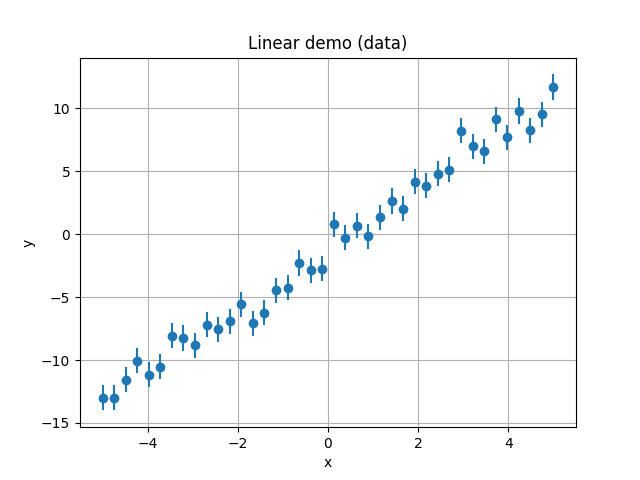

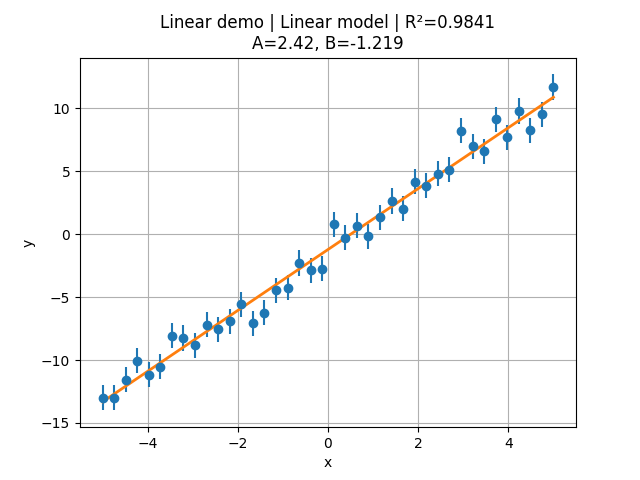

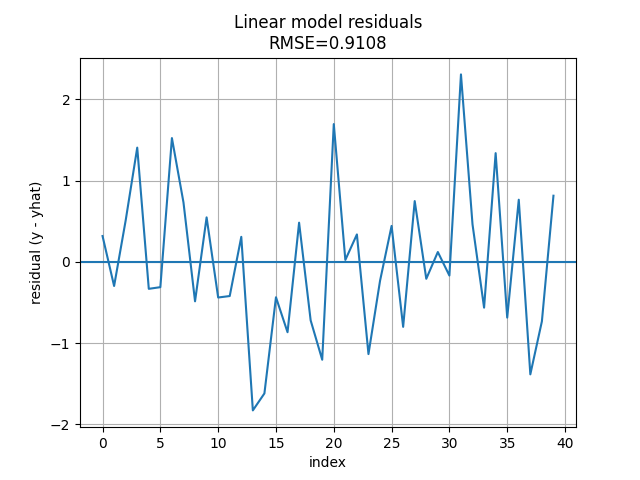

In [38]:
# -------------------------
# 4) Plot results
# -------------------------

# Data only
nr.plot(mode="data", dataset=ds)
plt.show()

# Data + fitted curve
nr.plot(mode="result_data", dataset=ds, result=res)
plt.show()

# Residuals
nr.plot(mode="result", result=res, dataset=ds, plot_mode="residuals")
plt.show()

>Making it shorter, you can use the built in models as shown under. This is the power of the nemreg library, that it only requires a few lines. 

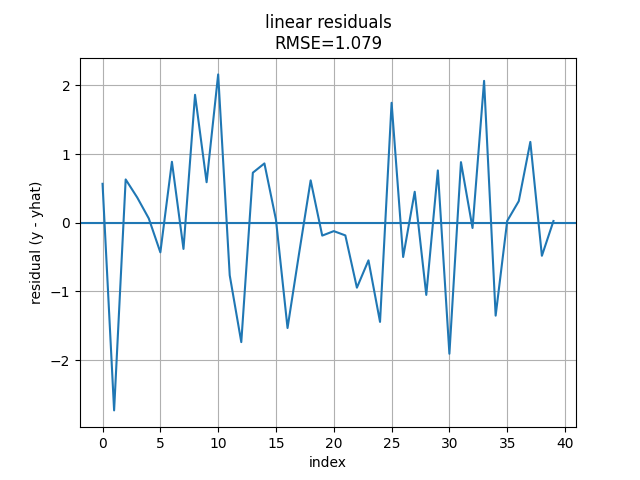

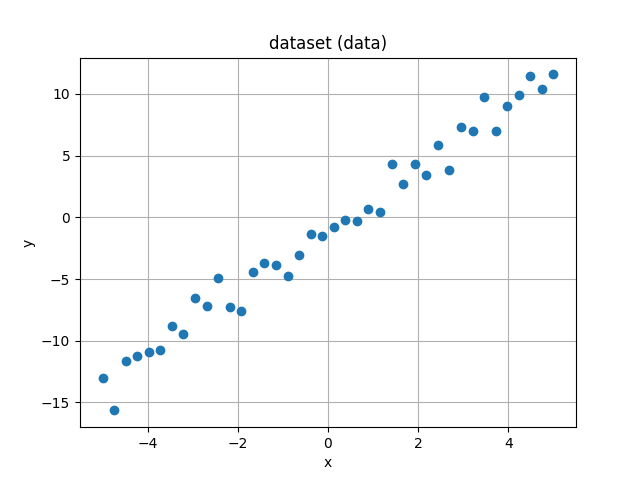

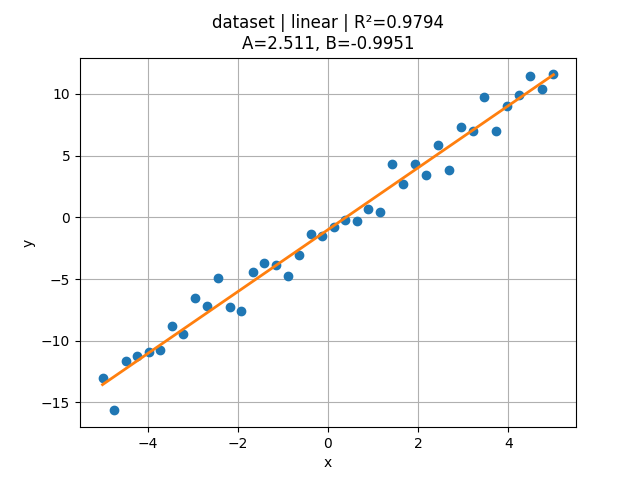

In [68]:
x = np.linspace(-5, 5, 40)
y = 2.5*x - 1 + np.random.normal(0, 1, size=x.size)

ds = nr.Dataset(x=x, y=y)
nr.plot(mode="data", dataset=ds)

res = nr.fit(ds, nr.models.linear())
nr.plot(mode="result_data", dataset=ds, result=res)

nr.plot(mode="result", result=res, dataset=ds, plot_mode="residuals")
plt.show()

<h3><center> 2 Dataset Features </center></h3>

<h4> 2.1 Shapes + Convensions </h4>

In [40]:
import numpy as np
import nemreg as nr

# X is always stored as (n, d) inside Dataset
n = 80
rng = np.random.default_rng(0)

x1 = rng.uniform(-3, 3, n)
x2 = rng.uniform(-3, 3, n)
y  = 2.0*x1 - 1.5*x2 + 4.0 + rng.normal(0, 0.8, n)

X = np.column_stack([x1, x2])  # (n,2)

ds = nr.Dataset(x=X, y=y, yerr=0.8, name="2-feature demo")
print("Dataset.x shape (stored):", ds.x.shape)     # (n, d)
print("Dataset.y shape:", ds.y.shape)              # (n,)
print("Fit will pass x to model as (d,n):", ds.x.T.shape)

model = nr.models.multivariable_linear(d=2)        # d = number of FEATURES (columns in X)
res = nr.fit(ds, model)
print(res.summary())

Dataset.x shape (stored): (80, 2)
Dataset.y shape: (80,)
Fit will pass x to model as (d,n): (2, 80)
Model: multi_variable_2
n=80, p=3, dof=77
  b = 3.90095 ± 0.090511
  a1 = 1.94014 ± 0.0506066
  a2 = -1.37128 ± 0.0478426
R²=0.966791, RMSE=0.806818, χ²=81.3695, χ²_red=1.05675


<h4> 2.2 Error Handling/Expansion </h4>

In [41]:
import numpy as np
import nemreg as nr

n = 10
x1 = np.linspace(0, 1, n)
x2 = np.linspace(1, 2, n)
X  = np.column_stack([x1, x2])
y  = 3*x1 - 2*x2 + 1

# Scalar errors should expand automatically
ds = nr.Dataset(x=X, y=y, xerr=0.05, yerr=0.2, name="error expansion")
print("x shape:", ds.x.shape)                 # (n,2)
print("xerr shape:", None if ds.xerr is None else ds.xerr.shape)  # should become (n,2)
print("y shape:", ds.y.shape)                 # (n,)
print("yerr shape:", None if ds.yerr is None else ds.yerr.shape)  # should become (n,)

# Mismatch should raise clean error
try:
    nr.Dataset(x=X, y=y[:-1])                 # wrong length
except Exception as e:
    print("Expected failure (mismatch):", type(e).__name__, "-", e)

x shape: (10, 2)
xerr shape: (10, 2)
y shape: (10,)
yerr shape: (10,)
Expected failure (mismatch): ValueError - y length must match number of rows in x


<h4> 2.3 Replicates → mean + std/sem </h4>

replicates (SEM per point) yerr shape: (25,) example yerr[0]: 0.13109486640046736
replicates (STD global) yerr type: <class 'numpy.ndarray'> value: [0.33524716 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716
 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716
 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716
 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716 0.33524716
 0.33524716]


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'replicates (SEM per point) | linear | R²=0.9973\nA=1.978, B=0.9568'}, xlabel='x', ylabel='y'>)

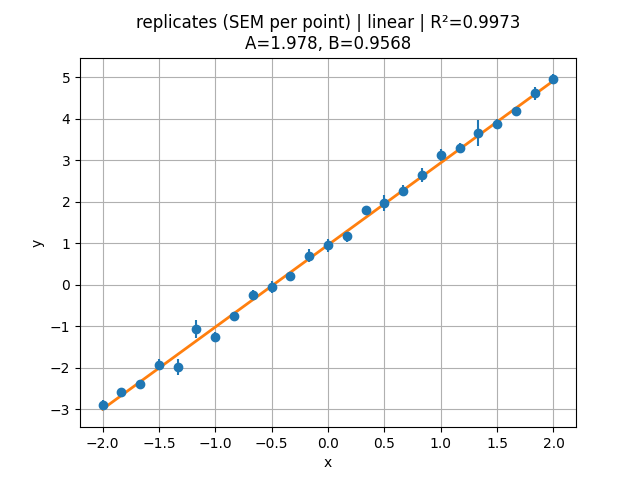

In [42]:
import numpy as np
import nemreg as nr

rng = np.random.default_rng(1)

n_points = 25
n_reps   = 6

x = np.linspace(-2, 2, n_points)

# Make replicate measurements Y: shape (n_points, n_reps)
true_y = 2.0*x + 1.0
Y = true_y[:, None] + rng.normal(0, 0.4, size=(n_points, n_reps))

# Build dataset from replicates:
# - y is mean over reps
# - yerr is SEM or STD (per-point) or global scalar depending on flags
ds_sem = nr.Dataset.from_replicates(
    x=x, Y=Y,
    yerr_mode="sem",
    yerr_global=False,
    name="replicates (SEM per point)"
)

ds_std_global = nr.Dataset.from_replicates(
    x=x, Y=Y,
    yerr_mode="std",
    yerr_global=True,
    name="replicates (STD global)"
)

print(ds_sem.name, "yerr shape:", ds_sem.yerr.shape, "example yerr[0]:", ds_sem.yerr[0])
print(ds_std_global.name, "yerr type:", type(ds_std_global.yerr), "value:", ds_std_global.yerr)

# Fit + plot for the SEM-per-point dataset (clean example)
res = nr.fit(ds_sem, nr.models.linear())
nr.plot(mode="result_data", dataset=ds_sem, result=res)

<h3><center> 3 Model Showcase </center></h3>

Model: linear
n=60, p=2, dof=58
  A = 2.55468 ± 0.0439821
  B = -0.922704 ± 0.129099
R²=0.986324, RMSE=0.882988, χ²=46.7801, χ²_red=0.806553
expr: A*x + B
latex: A \cdot x + B


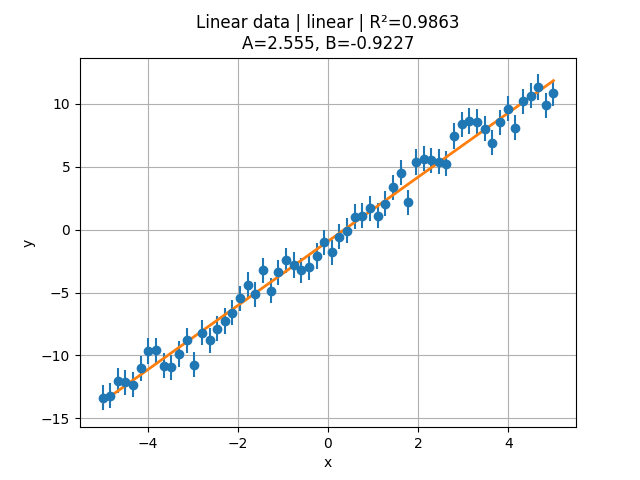

In [43]:
rng = np.random.default_rng(0)
x = np.linspace(-5, 5, 60)
y = 2.5*x - 1.0 + rng.normal(0, 1.0, size=x.size)
ds = nr.Dataset(x=x, y=y, yerr=1.0, name="Linear data")

m = nr.models.linear()
res = nr.fit(ds, m)

print(res.summary())
print("expr:", getattr(res.model, "expr", None))
print("latex:", getattr(res.model, "latex", None))

nr.plot(mode="result_data", dataset=ds, result=res)
plt.show()

Model: poly4
n=80, p=5, dof=75
  c0 = 0.963356 ± 0.0733978
  c1 = 0.525324 ± 0.0837148
  c2 = -2.0029 ± 0.112166
  c3 = -0.0188431 ± 0.0311895
  c4 = 0.204624 ± 0.0305963
R²=0.970937, RMSE=0.291886, χ²=55.6392, χ²_red=0.741856
expr: c0 + c1*x + c2*x**2 + c3*x**3 + c4*x**4
latex: c0 + c1 x + c2 x^2 + c3 x^3 + c4 x^4


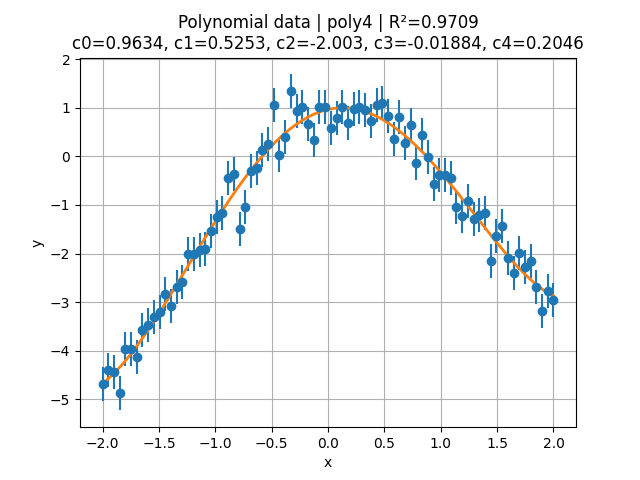

In [44]:
rng = np.random.default_rng(1)
x = np.linspace(-2, 2, 80)
y = 1.0 + 0.5*x - 2.0*x**2 + 0.2*x**4 + rng.normal(0, 0.35, size=x.size)
ds = nr.Dataset(x=x, y=y, yerr=0.35, name="Polynomial data")

m = nr.models.polynomial(4)   # user chooses degree (0..10)
res = nr.fit(ds, m)

print(res.summary())
print("expr:", getattr(res.model, "expr", None))
print("latex:", getattr(res.model, "latex", None))

nr.plot(mode="result_data", dataset=ds, result=res)
plt.show()

Model: multi_variable_2
n=120, p=3, dof=117
  b = 3.89378 ± 0.0730847
  a1 = 2.02532 ± 0.0418821
  a2 = -1.43059 ± 0.0407624
R²=0.96699, RMSE=0.817799, χ²=125.399, χ²_red=1.07179
expr: b + a1*x1 + a2*x2
latex: b + a_1 x_1 + a_2 x_2


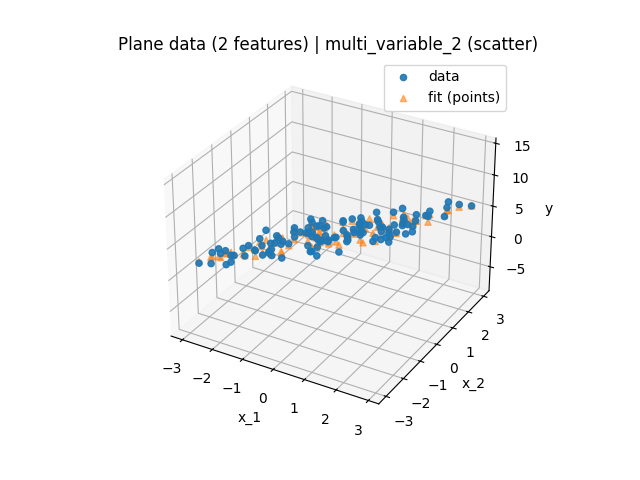

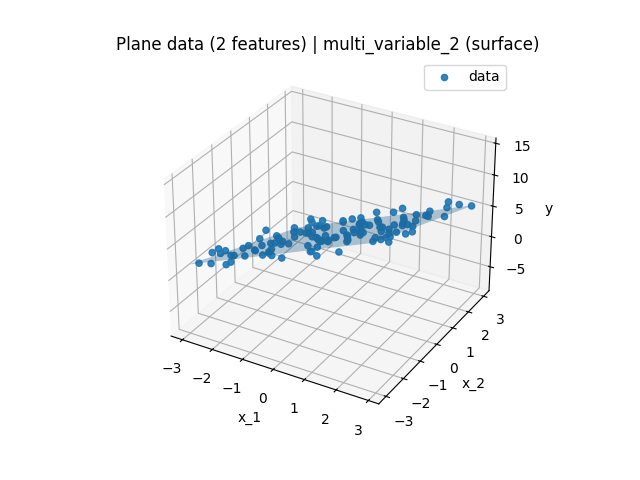

In [45]:
rng = np.random.default_rng(2)
n = 120
x1 = rng.uniform(-3, 3, n)
x2 = rng.uniform(-3, 3, n)
z  = 2.0*x1 - 1.5*x2 + 4.0 + rng.normal(0, 0.8, n)

X = np.column_stack([x1, x2])                 # (n,2)
ds = nr.Dataset(x=X, y=z, yerr=0.8, name="Plane data (2 features)")

m = nr.models.multivariable_linear(d=2)       # d = number of FEATURES (columns in X)
res = nr.fit(ds, m)

print(res.summary())
print("expr:", getattr(res.model, "expr", None))
print("latex:", getattr(res.model, "latex", None))

# scatter + predicted points
nr.plot(mode="multivariable", dataset=ds, result=res, kind="scatter")
plt.show()

# surface (the plane)
nr.plot(mode="multivariable", dataset=ds, result=res, kind="surface", grid_size=60)
plt.show()

<h3><center> 4 Fitting Behaviour </center></h3>

DEFAULT:
 Model: power_offset
n=60, p=3, dof=57
  C = 3.1254 ± 0.139049
  n = 1.67266 ± 0.0391262
  B = 0.373219 ± 0.14191
R²=0.996494, RMSE=0.351708, χ²=46.387, χ²_red=0.813807

USER p0:
 Model: power_offset
n=60, p=3, dof=57
  C = 3.1254 ± 0.139048
  n = 1.67266 ± 0.0391264
  B = 0.373217 ± 0.141909
R²=0.996494, RMSE=0.351708, χ²=46.387, χ²_red=0.813807


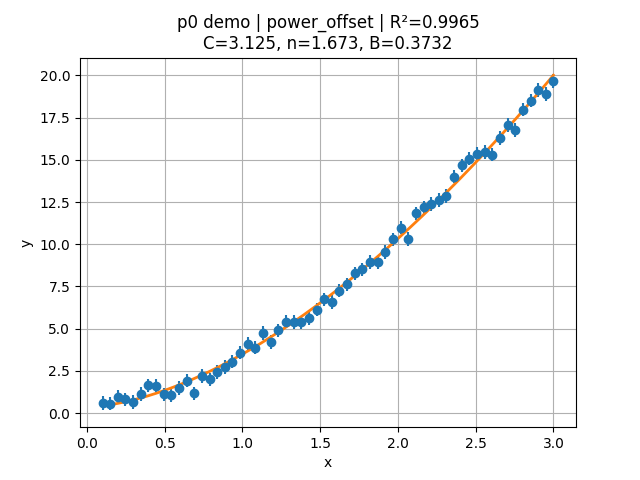

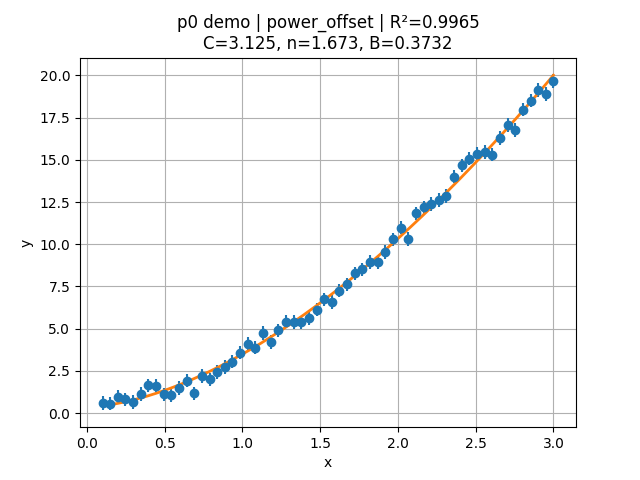

In [46]:
import numpy as np, nemreg as nr, matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.linspace(0.1, 3.0, 60)
y = 3.0 * x**1.7 + 0.5 + rng.normal(0, 0.4, x.size)
ds = nr.Dataset(x=x, y=y, yerr=0.4, name="p0 demo")

m = nr.models.power()  # assumes you have C*x^n + B style model

# (A) default: model.guess or ones
res_default = nr.fit(ds, m)

# (B) user forces p0
res_p0 = nr.fit(ds, m, p0=[1.0, 1.0, 0.0])  # (C,n,B) example ordering

print("DEFAULT:\n", res_default.summary())
print("\nUSER p0:\n", res_p0.summary())

nr.plot(mode="result_data", dataset=ds, result=res_default)
plt.show()

nr.plot(mode="result_data", dataset=ds, result=res_p0)
plt.show()

WEIGHTED:
 Model: linear
n=80, p=2, dof=78
  A = 1.9322 ± 0.0335499
  B = -1.12027 ± 0.132448
R²=0.978826, RMSE=0.849264, χ²=112.433, χ²_red=1.44144

UNWEIGHTED:
 Model: linear
n=80, p=2, dof=78
  A = 1.97596 ± 0.0324669
  B = -1.07158 ± 0.0949029
R²=0.979376, RMSE=0.83816, χ²=nan, χ²_red=nan


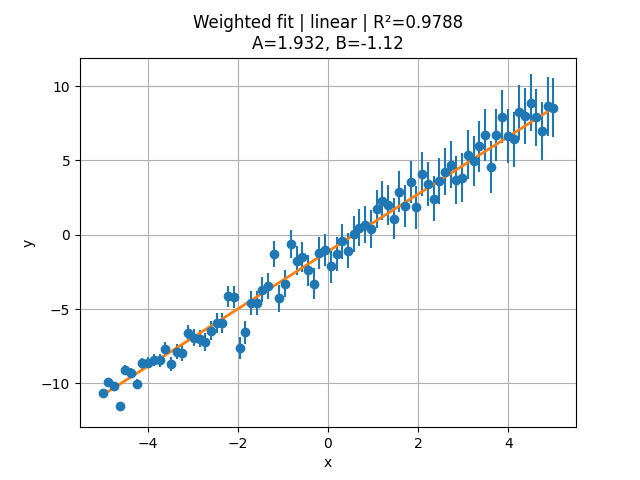

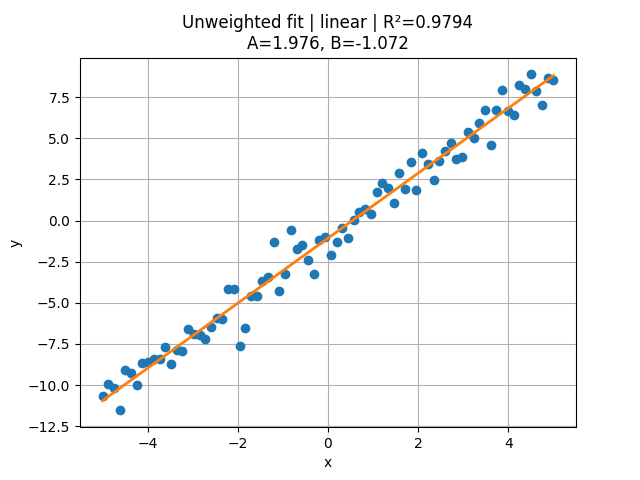

In [47]:
import numpy as np, nemreg as nr, matplotlib.pyplot as plt

rng = np.random.default_rng(1)
x = np.linspace(-5, 5, 80)
y_true = 2.0*x - 1.0
y = y_true + rng.normal(0, 1.0, x.size)

# make left side "more precise" than right side
yerr = np.linspace(0.2, 2.0, x.size)

ds_w = nr.Dataset(x=x, y=y, yerr=yerr, name="Weighted fit")
ds_u = nr.Dataset(x=x, y=y, yerr=None, name="Unweighted fit")

m = nr.models.linear()

res_w = nr.fit(ds_w, m)     # weighted
res_u = nr.fit(ds_u, m)     # unweighted

print("WEIGHTED:\n", res_w.summary())
print("\nUNWEIGHTED:\n", res_u.summary())

nr.plot(mode="result_data", dataset=ds_w, result=res_w)
plt.show()

nr.plot(mode="result_data", dataset=ds_u, result=res_u)
plt.show()

FREE:
 Model: linear
n=50, p=2, dof=48
  A = -1.49509 ± 0.0240098
  B = 0.206586 ± 0.0424264
R²=0.987774, RMSE=0.293915, χ²=47.9923, χ²_red=0.999839

BOUNDED (A>=0):
 Model: linear
n=50, p=2, dof=48
  A = 8.55693e-20 ± 0.0240098
  B = 0.206586 ± 0.0424264
R²=0, RMSE=2.65819, χ²=3925.54, χ²_red=81.7821


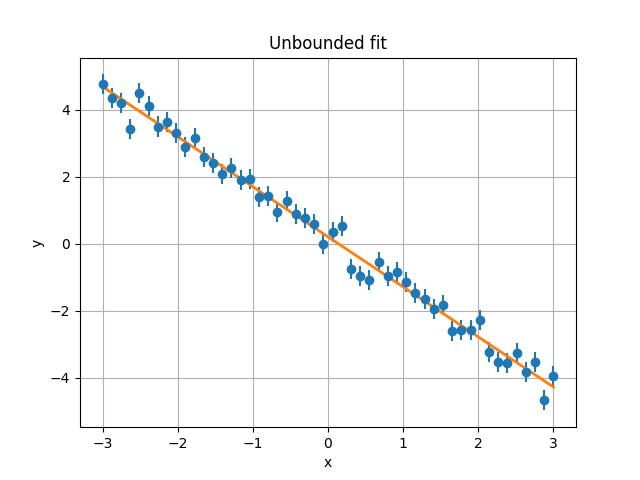

/Users/nemeth/Programing/DTU_Programming/Test/nemreg/src/nemreg/plotting/plot_result_data.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


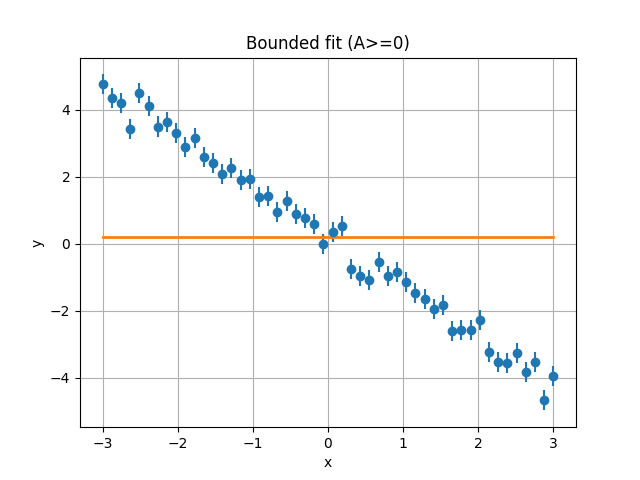

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import nemreg as nr

# ----------------------------
# Data
# ----------------------------
rng = np.random.default_rng(2)
x = np.linspace(-3, 3, 50)
y = -1.5 * x + 0.2 + rng.normal(0, 0.3, size=x.size)

ds = nr.Dataset(x=x, y=y, yerr=0.3, name="Bounds demo")
m = nr.models.linear()  # expects param_names ("A","B")

# ----------------------------
# Unbounded fit
# ----------------------------
res_free = nr.fit(ds, m)

# ----------------------------
# Bounded fit: A >= 0, B free
# IMPORTANT: p0 must be inside bounds
# ----------------------------
lo = np.array([0.0, -np.inf], dtype=float)
hi = np.array([np.inf, np.inf], dtype=float)

res_bound = nr.fit(
    ds,
    m,
    bounds=(lo, hi),
    p0=[0.1, float(np.mean(ds.y))],  # valid start: A>=0
    method="trf",                    # safest when using bounds
)

# ----------------------------
# Print summaries
# ----------------------------
print("FREE:\n", res_free.summary())
print("\nBOUNDED (A>=0):\n", res_bound.summary())

# ----------------------------
# Plots
# ----------------------------
nr.plot(mode="result_data", dataset=ds, result=res_free, title="Unbounded fit")
plt.show()

nr.plot(mode="result_data", dataset=ds, result=res_bound, title="Bounded fit (A>=0)")
plt.show()

Model: multi_variable_2
n=120, p=3, dof=117
  b = 1.03782 ± 0.0457025
  a1 = 2.98039 ± 0.0427257
  a2 = -2.05728 ± 0.0424564
R²=0.985801, RMSE=0.501316, χ²=120.632, χ²_red=1.03105


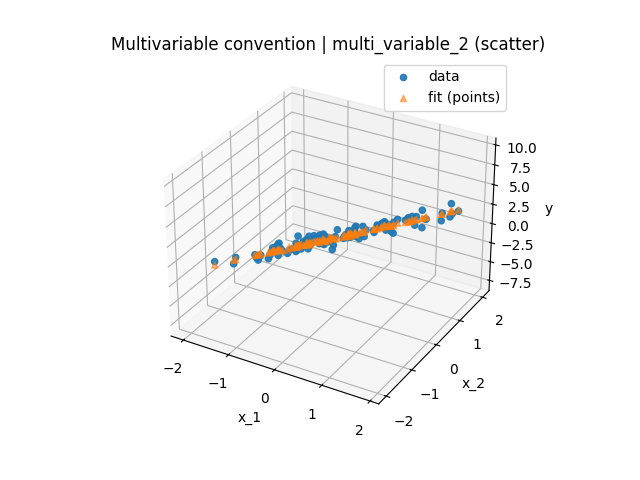

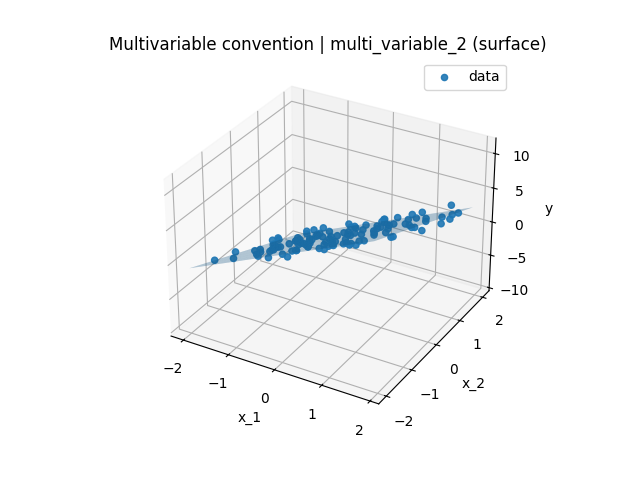

In [49]:
import numpy as np, nemreg as nr, matplotlib.pyplot as plt

rng = np.random.default_rng(3)
n = 120
x1 = rng.uniform(-2, 2, n)
x2 = rng.uniform(-2, 2, n)
y  = 1.0 + 3.0*x1 - 2.0*x2 + rng.normal(0, 0.5, n)

X = np.column_stack([x1, x2])        # (n,2) ✅ user-facing
ds = nr.Dataset(x=X, y=y, yerr=0.5, name="Multivariable convention")

m = nr.models.multivariable_linear(d=2)  # d = number of FEATURES (columns)
res = nr.fit(ds, m)

print(res.summary())

# scatter + predicted points
nr.plot(mode="multivariable", dataset=ds, result=res, kind="scatter")
plt.show()

# show fitted plane
nr.plot(mode="multivariable", dataset=ds, result=res, kind="surface", grid_size=60)
plt.show()

<h3><center> 5 Plotting API Coverage </center></h3>

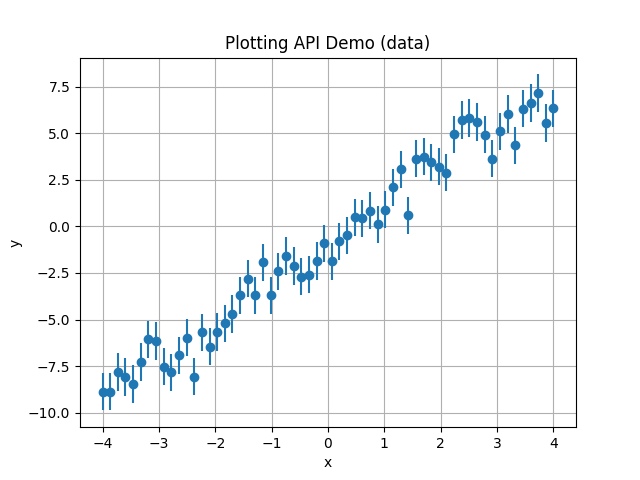

In [50]:
import numpy as np
import nemreg as nr
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.linspace(-4, 4, 60)
y = 2.0*x - 1.0 + rng.normal(0, 1.0, size=x.size)

ds = nr.Dataset(x=x, y=y, yerr=1.0, name="Plotting API Demo")

nr.plot(mode="data", dataset=ds)
plt.show()

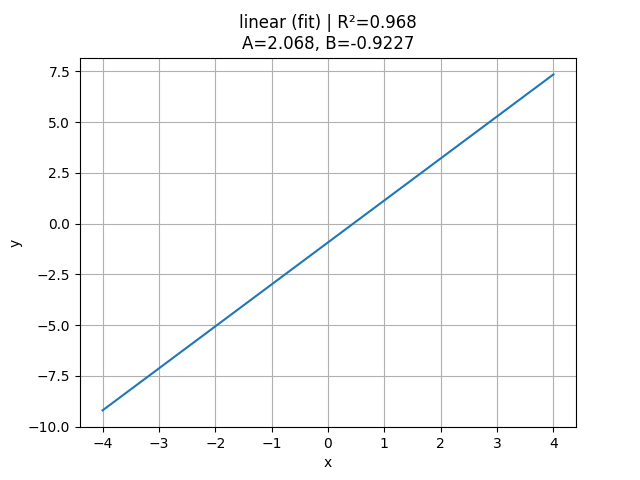

In [51]:
m = nr.models.linear()
res = nr.fit(ds, m)

nr.plot(mode="result", dataset=ds, result=res, plot_mode="fit")
plt.show()

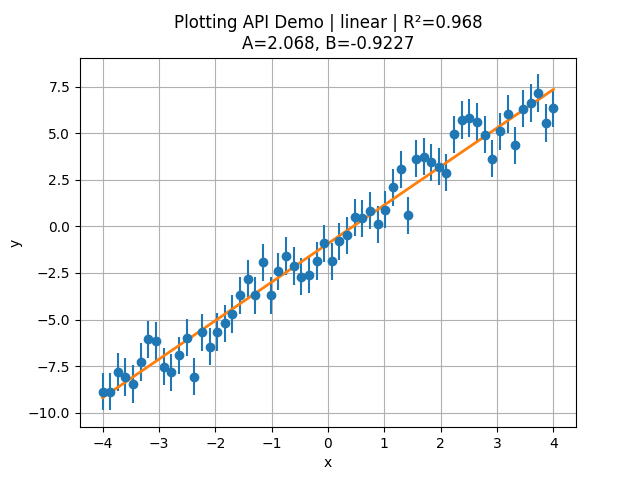

In [52]:
nr.plot(mode="result_data", dataset=ds, result=res)
plt.show()

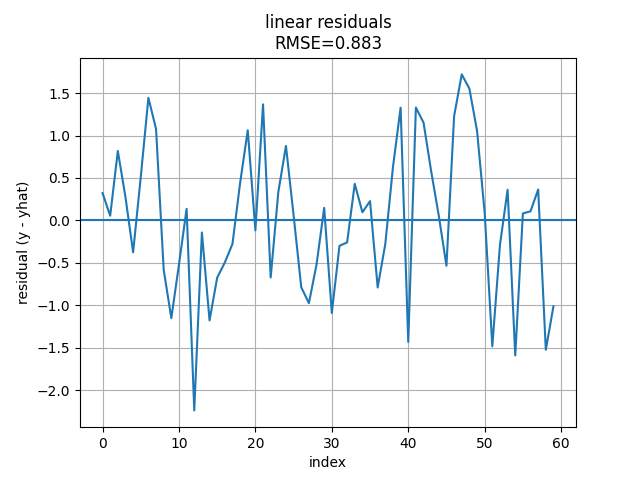

In [53]:
nr.plot(mode="result", result=res, plot_mode="residuals")
plt.show()

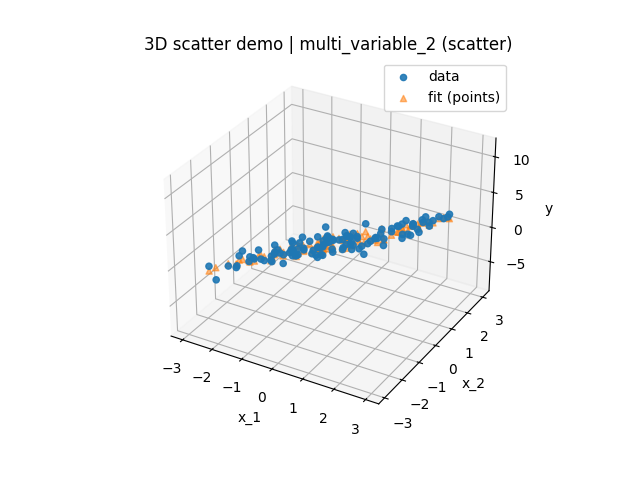

In [54]:
rng = np.random.default_rng(1)
n = 120
x1 = rng.uniform(-3, 3, n)
x2 = rng.uniform(-3, 3, n)
z  = 1.0 + 2.0*x1 - 1.5*x2 + rng.normal(0, 0.8, n)

X = np.column_stack([x1, x2])
ds2 = nr.Dataset(x=X, y=z, yerr=0.8, name="3D scatter demo")

m2 = nr.models.multivariable_linear(d=2)
res2 = nr.fit(ds2, m2)

nr.plot(mode="multivariable", dataset=ds2, result=res2, kind="scatter")
plt.show()

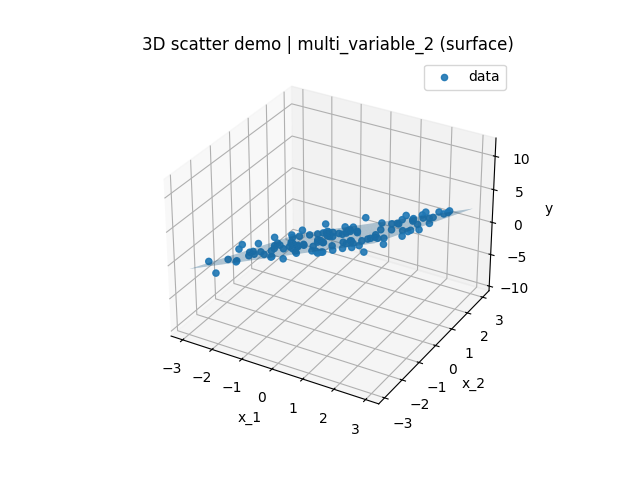

In [55]:
nr.plot(
    mode="multivariable",
    dataset=ds2,
    result=res2,
    kind="surface",
    grid_size=60
)
plt.show()

<h3><center> 6 Multivariable Plotting (2D & 3D) </center></h3>

##### Example with 2D

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'dataset | linear | R²=0.9953\nA=2.867, B=3.185'}, xlabel='x', ylabel='y'>)

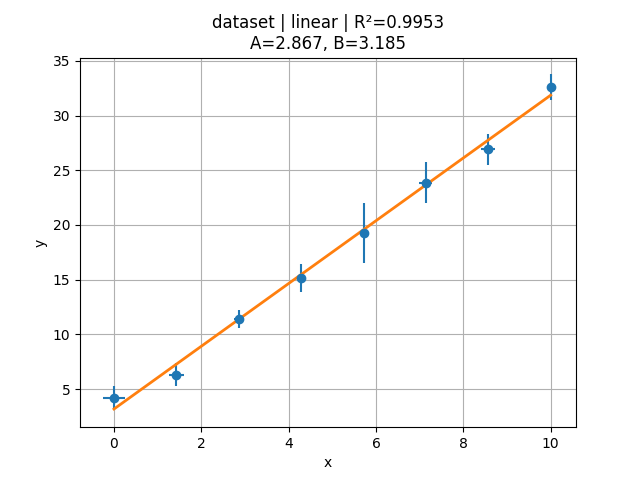

In [56]:
import numpy as np, nemreg as nr
np.random.seed(0)

x = np.linspace(0, 10, 8)
Y = 3*x[:,None] + 2 + np.random.normal(0, 1.5, (8, 5))  # 5 measurements per x
X = x[:,None] + np.random.normal(0, 0.2, (8, 5))         # x uncertainty

ds = nr.Dataset.from_replicates(
    x=x,
    Y=Y,
    yerr_mode="std",
    xerr=np.std(X, axis=1)
)

res = nr.fit(ds, nr.models.linear())
nr.plot(mode="result_data", dataset=ds, result=res)

##### Example in 3D

>IMPORTANT: If running in Jupyter, install ipympl using ```python -m pip install ipympl``` to get interactive plot

In [57]:
%matplotlib widget

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: title={'center': 'dataset | multi_variable_2 (surface)'}, xlabel='x_1', ylabel='x_2', zlabel='y'>)

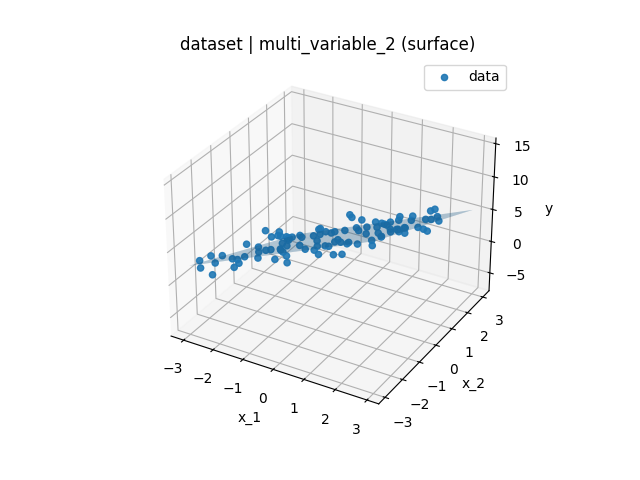

In [58]:
import numpy as np, nemreg as nr
np.random.seed(1)

x1 = np.random.uniform(-3, 3, 100)
x2 = np.random.uniform(-3, 3, 100)
z  = 2*x1 - 1.5*x2 + 4 + np.random.normal(0, 1.0, 100)

X = np.column_stack((x1, x2))
ds = nr.Dataset(x=X, y=z, yerr=1.0)

res = nr.fit(ds, nr.models.multivariable_linear(d=2))
nr.plot(mode="multivariable", dataset=ds, result=res, kind="surface")

<h3><center> 7 Dataset Example </center></h3>

In [59]:
import numpy as np
import nemreg as nr
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_points = 40        # number of unique x points
n_reps   = 25        # repeated measurements per point

x = np.linspace(-5, 5, n_points)

# True underlying model
true_y = 1.0 + 2.5*x - 0.8*x**2

# Create replicate matrix: shape (n_points, n_reps)
Y = true_y[:, None] + rng.normal(0, 1.2, size=(n_points, n_reps))

print("Raw replicate shape:", Y.shape)

Raw replicate shape: (40, 25)


In [60]:
ds_sem = nr.Dataset.from_replicates(
    x=x,
    Y=Y,
    yerr_mode="sem",      # "std" or "sem"
    yerr_global=False,    # False → each point has its own uncertainty
    name="Replicates (SEM per point)"
)

print("Dataset y shape:", ds_sem.y.shape)
print("Dataset yerr shape:", ds_sem.yerr.shape)

Dataset y shape: (40,)
Dataset yerr shape: (40,)


In [61]:
ds_std_global = nr.Dataset.from_replicates(
    x=x,
    Y=Y,
    yerr_mode="std",
    yerr_global=True,     # single scalar error
    name="Replicates (Global STD)"
)

print("Global yerr:", ds_std_global.yerr)

Global yerr: [1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922 1.16960922
 1.16960922 1.16960922 1.16960922 1.16960922]


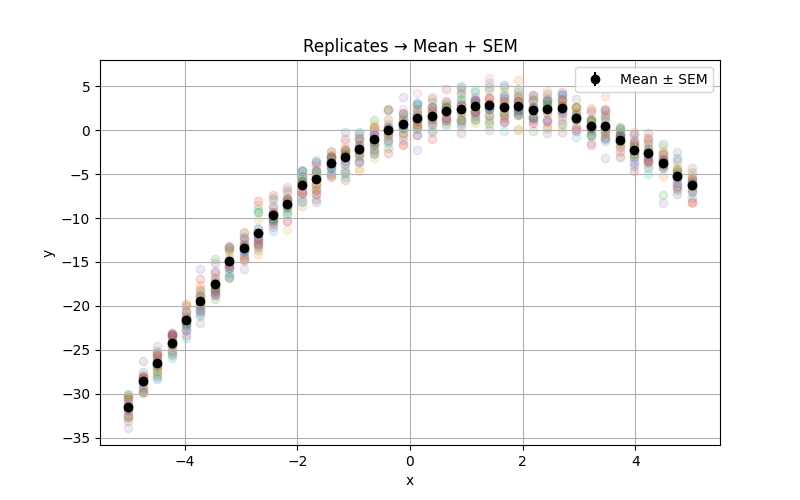

In [62]:
plt.figure(figsize=(8,5))

# Raw replicate cloud
for i in range(n_reps):
    plt.scatter(x, Y[:, i], alpha=0.15)

# Aggregated mean with SEM bars
plt.errorbar(ds_sem.x[:,0], ds_sem.y, yerr=ds_sem.yerr,
             fmt="o", color="black", label="Mean ± SEM")

plt.title("Replicates → Mean + SEM")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Model: poly2
n=40, p=3, dof=37
  c0 = 0.957522 ± 0.054935
  c1 = 2.49438 ± 0.0116
  c2 = -0.799039 ± 0.00439636
R²=0.999377, RMSE=0.241649, χ²=47.2191, χ²_red=1.27619


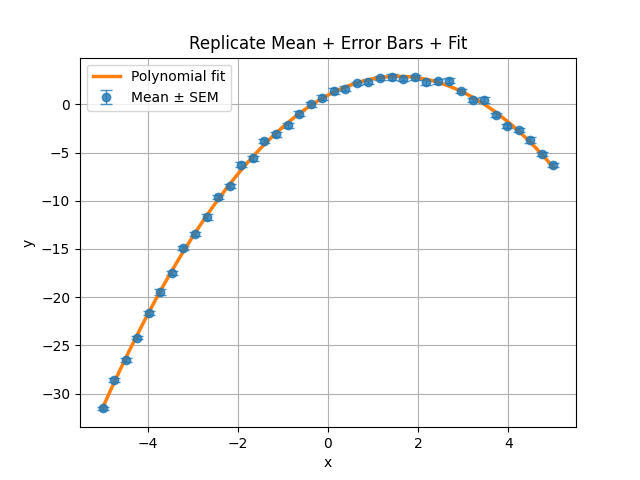

In [63]:
import matplotlib.pyplot as plt

m = nr.models.polynomial(2)
res = nr.fit(ds_sem, m)

print(res.summary())

# Create figure manually for full control
fig, ax = plt.subplots()

# --- Error bars (mean ± SEM) ---
ax.errorbar(
    ds_sem.x[:, 0],        # x stored as (n,1)
    ds_sem.y,
    yerr=ds_sem.yerr,
    fmt="o",
    capsize=4,
    elinewidth=1,
    alpha=0.8,
    label="Mean ± SEM",
)

# --- Fitted curve ---
xg = np.linspace(ds_sem.x[:,0].min(), ds_sem.x[:,0].max(), 500)
yg = res.predict(xg)

ax.plot(xg, yg, linewidth=2.5, label="Polynomial fit")

ax.set_title("Replicate Mean + Error Bars + Fit")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()

plt.show()

<h3><center> 8 How to Extend NEMREG </center></h3>

Model: power_custom
n=80, p=3, dof=77
  C = 2.17202 ± 0.0544299
  n = 1.70617 ± 0.0136559
  B = 0.648175 ± 0.118236
R²=0.999545, RMSE=0.293075, χ²=56.0933, χ²_red=0.728485


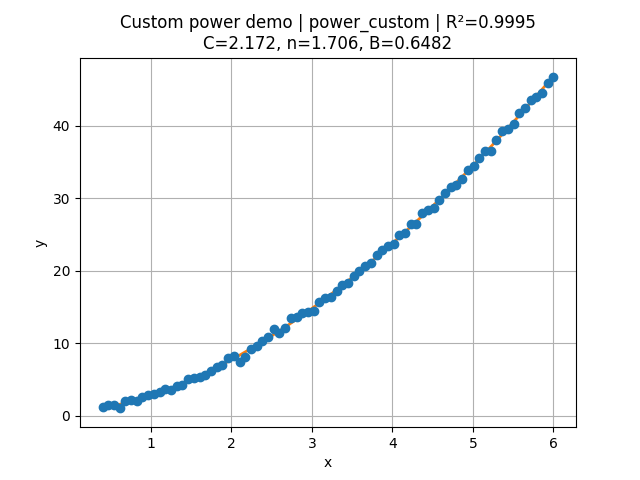


Symbolic expression (text):
B + C*x**n

Symbolic expression (LaTeX string):
B + C x^{n}


<IPython.core.display.Math object>


Fitted expression (text):
2.17202290366719*x**1.70616702677678 + 0.648175088469972

Fitted expression (LaTeX):


<IPython.core.display.Math object>

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math
import nemreg as nr

# ----------------------------
# 1) Synthetic data
# ----------------------------
rng = np.random.default_rng(1)

x = np.linspace(0.4, 6.0, 80)
C_true, n_true, B_true = 2.2, 1.7, 0.6
sigma = 0.35

y = C_true * (x**n_true) + B_true + rng.normal(0, sigma, size=x.size)

ds = nr.Dataset(
    x=x,
    y=y,
    yerr=sigma,
    name="Custom power demo",
)

# ----------------------------
# 2) Custom model
# ----------------------------
m = nr.models.custom(
    "C*x**n + B",
    var="x",
    param_order=["C", "n", "B"],
    name="power_custom",
)

p0 = [1.0, 1.5, 0.0]

# ----------------------------
# 3) Fit
# ----------------------------
res = nr.fit(ds, m, p0=p0)

print(res.summary())

# ----------------------------
# 4) Plot
# ----------------------------
nr.plot(mode="result_data", dataset=ds, result=res)
plt.show()

# ----------------------------
# 5) Print symbolic expressions
# ----------------------------
print("\nSymbolic expression (text):")
print(res.model.expr)

print("\nSymbolic expression (LaTeX string):")
print(res.model.latex)

# Render LaTeX nicely in Jupyter
display(Math(res.model.latex))

# ----------------------------
# 6) Print fitted expression with numbers inserted
# ----------------------------
expr_sym = sp.sympify(res.model.expr)

subs_dict = {
    sp.Symbol(name): value
    for name, value in zip(res.model.param_names, res.popt)
}

expr_fitted = expr_sym.subs(subs_dict)

print("\nFitted expression (text):")
print(expr_fitted)

print("\nFitted expression (LaTeX):")
display(Math(sp.latex(expr_fitted)))

<h3><center> 9 Session API  </center></h3>

(If you want it public)

<h3><center> 10 Limitations </center></h3>

> 
>The library has some limitatios as stated under
>
> * dimensions <= 3 
> * polynomial <= 10 
> 
>
>
>

